<a href="https://colab.research.google.com/github/SaanviGoel30/Portfolio-Optimisation/blob/main/Portfolio_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [3]:
NUM_TRADING_DAYS = 252
NUM_SIMULATIONS = 100000
stocks = ['RELIANCE.NS' , 'TCS.NS' ,
          'HINDUNILVR.NS' , 'HDFCBANK.NS' ,
          'ITC.NS' , 'LT.NS' , 'INFY.NS']
start_date = "2018-01-01"
end_date = "2024-09-01"

In [4]:
stock_data={}
for i in stocks:
  ticker = yf.Ticker(i)
  stock_data[i] = ticker.history(start = start_date,
                                 end = end_date,)['Close']
stock_prices = pd.DataFrame(stock_data)

In [5]:
stock_prices

,RELIANCE.NS,TCS.NS,HINDUNILVR.NS,HDFCBANK.NS,ITC.NS,LT.NS,INFY.NS
Date,,,,,,,
2018-01-01 00:00:00+05:30,399.465149,1170.666016,1210.935181,877.075317,204.714600,1128.959961,436.195038
2018-01-02 00:00:00+05:30,400.079834,1164.294434,1205.621216,885.517395,203.504868,1119.154175,434.570160
2018-01-03 00:00:00+05:30,401.682526,1167.590820,1216.203857,876.200317,203.817047,1142.034058,431.025085
2018-01-04 00:00:00+05:30,404.097534,1175.754639,1217.915405,879.629272,204.129242,1178.212524,428.535004
2018-01-05 00:00:00+05:30,405.392914,1189.958862,1221.788086,881.379089,205.182846,1177.496094,427.100128
...,...,...,...,...,...,...,...
2024-08-26 00:00:00+05:30,1512.599976,4491.492676,2799.890625,1639.949951,505.700012,3641.899902,1855.028442
2024-08-27 00:00:00+05:30,1500.449951,4486.205566,2746.049561,1637.750000,500.600006,3702.699951,1878.708740
2024-08-28 00:00:00+05:30,1498.300049,4495.083496,2743.519043,1637.099976,497.299988,3689.050049,1917.269653


In [6]:
log_returns = np.log(stock_prices/stock_prices.shift(1))

In [7]:
log_returns

,RELIANCE.NS,TCS.NS,HINDUNILVR.NS,HDFCBANK.NS,ITC.NS,LT.NS,INFY.NS
Date,,,,,,,
2018-01-01 00:00:00+05:30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-02 00:00:00+05:30,0.001538,-0.005458,-0.004398,0.009579,-0.005927,-0.008724,-0.003732
2018-01-03 00:00:00+05:30,0.003998,0.002827,0.008739,-0.010577,0.001533,0.020238,-0.008191
2018-01-04 00:00:00+05:30,0.005994,0.006968,0.001406,0.003906,0.001531,0.031188,-0.005794
2018-01-05 00:00:00+05:30,0.003200,0.012009,0.003175,0.001987,0.005148,-0.000608,-0.003354
...,...,...,...,...,...,...,...
2024-08-26 00:00:00+05:30,0.008382,0.008599,0.001969,0.009127,-0.000198,0.011974,0.007517
2024-08-27 00:00:00+05:30,-0.008065,-0.001178,-0.019417,-0.001342,-0.010136,0.016557,0.012685
2024-08-28 00:00:00+05:30,-0.001434,0.001977,-0.000922,-0.000397,-0.006614,-0.003693,0.020317


In [8]:
log_returns.dropna()


,RELIANCE.NS,TCS.NS,HINDUNILVR.NS,HDFCBANK.NS,ITC.NS,LT.NS,INFY.NS
Date,,,,,,,
2018-01-02 00:00:00+05:30,0.001538,-0.005458,-0.004398,0.009579,-0.005927,-0.008724,-0.003732
2018-01-03 00:00:00+05:30,0.003998,0.002827,0.008739,-0.010577,0.001533,0.020238,-0.008191
2018-01-04 00:00:00+05:30,0.005994,0.006968,0.001406,0.003906,0.001531,0.031188,-0.005794
2018-01-05 00:00:00+05:30,0.003200,0.012009,0.003175,0.001987,0.005148,-0.000608,-0.003354
2018-01-08 00:00:00+05:30,0.005724,0.009327,0.008698,-0.001611,0.010218,0.017602,0.023487
...,...,...,...,...,...,...,...
2024-08-26 00:00:00+05:30,0.008382,0.008599,0.001969,0.009127,-0.000198,0.011974,0.007517
2024-08-27 00:00:00+05:30,-0.008065,-0.001178,-0.019417,-0.001342,-0.010136,0.016557,0.012685
2024-08-28 00:00:00+05:30,-0.001434,0.001977,-0.000922,-0.000397,-0.006614,-0.003693,0.020317


In [10]:
print("Stocks       Annulaised Returns(%)")
print(log_returns.mean()*NUM_TRADING_DAYS*100)

Stocks       Annulaised Returns(%)
RELIANCE.NS      20.391448
TCS.NS           20.797158
HINDUNILVR.NS    12.619542
HDFCBANK.NS       9.570273
ITC.NS           13.754692
LT.NS            18.225780
INFY.NS          22.744992
dtype: float64


In [11]:
print("Stocks       Volatility(Risk)")
print(np.std(log_returns)*np.sqrt(NUM_TRADING_DAYS))


Stocks       Volatility(Risk)
RELIANCE.NS      0.292106
TCS.NS           0.246211
HINDUNILVR.NS    0.228613
HDFCBANK.NS      0.253351
ITC.NS           0.248893
LT.NS            0.276867
INFY.NS          0.276065
dtype: float64


/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


In [12]:
portfolio_return=[]
portfolio_risk=[]
portfolio_weight=[]

In [13]:
for _ in range (NUM_SIMULATIONS):
  w = np.random.random(len(stocks))
  w/=np.sum(w)
  portfolio_weight.append(w)
  p_return = np.sum(log_returns.mean()*w)*NUM_TRADING_DAYS
  portfolio_return.append(p_return)
  p_risk = np.sqrt(np.dot(w.T,
        np.dot(log_returns.cov()*NUM_TRADING_DAYS,w)))
  portfolio_risk.append(p_risk)

In [14]:
portfolio_weight = np.array(portfolio_weight)
portfolio_risk = np.array(portfolio_risk)
portfolio_return = np.array(portfolio_return)

In [15]:
portfolios = pd.DataFrame({"Returns" : portfolio_return,
                          "Risk" : portfolio_risk ,
              "Sharpe_Ratio":portfolio_return/portfolio_risk})

In [16]:
portfolios

,Returns,Risk,Sharpe_Ratio
0,0.161180,0.164301,0.981005
1,0.182897,0.175319,1.043222
2,0.172080,0.171863,1.001264
3,0.174822,0.174398,1.002431
4,0.168957,0.170407,0.991491
...,...,...,...
99995,0.165070,0.174995,0.943288
99996,0.189900,0.185754,1.022316
99997,0.160995,0.179913,0.894848
99998,0.172550,0.175866,0.981143


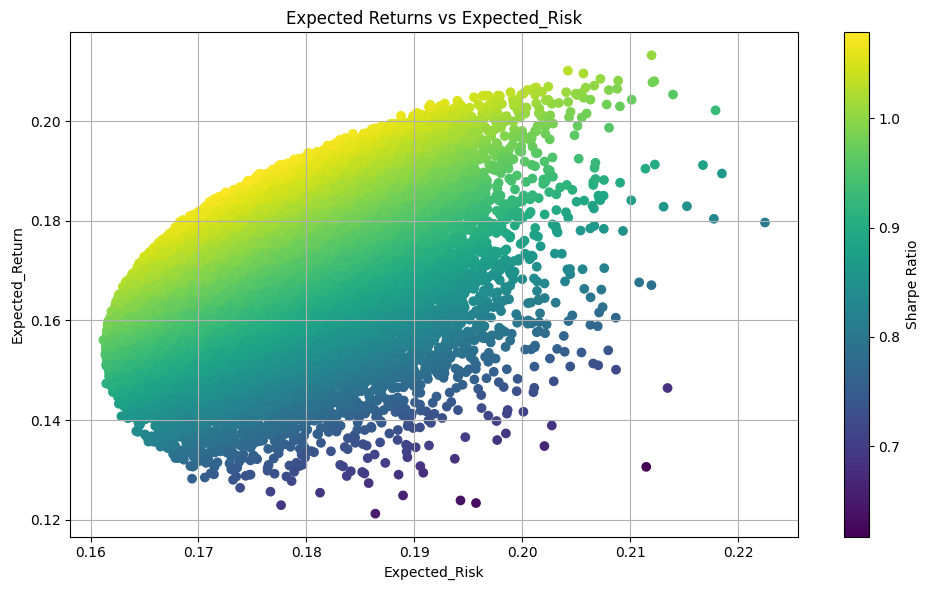

In [17]:
plt.figure(figsize=(10,6))
plt.scatter(portfolio_risk,portfolio_return,
            c=portfolio_return/portfolio_risk,marker='o')
plt.grid(True)
plt.xlabel('Expected_Risk')
plt.ylabel('Expected_Return')
plt.colorbar(label = "Sharpe Ratio")
plt.title("Expected Returns vs Expected_Risk")
plt.tight_layout()

In [18]:
sharpe_ratio=portfolio_return/portfolio_risk

In [19]:
ind=0

for i in range(len(sharpe_ratio)):
  if(sharpe_ratio[i]==np.max(sharpe_ratio)):
    ind=i

In [20]:
print("Stocks with their corresponding weights")
for i in range(len(stocks)):
  print(stocks[i],"---->",
        np.round(portfolio_weight[ind][i],5))

Stocks with their corresponding weights
RELIANCE.NS ----> 0.15127
TCS.NS ----> 0.24583
HINDUNILVR.NS ----> 0.096
HDFCBANK.NS ----> 0.00125
ITC.NS ----> 0.13251
LT.NS ----> 0.17489
INFY.NS ----> 0.19826


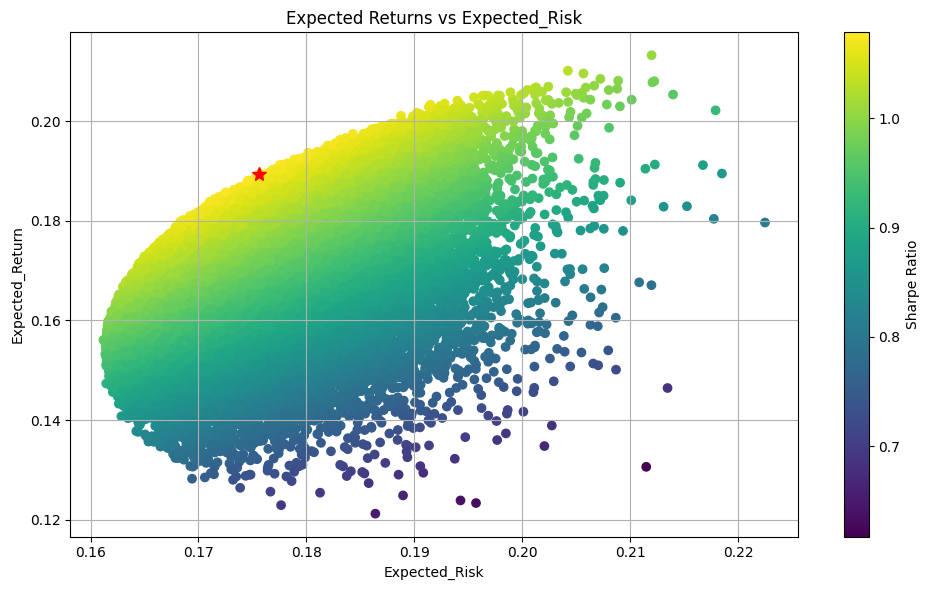

In [21]:
plt.figure(figsize=(10,6))
plt.scatter(portfolio_risk,portfolio_return,
            c=portfolio_return/portfolio_risk,marker='o')
plt.grid(True)
plt.xlabel('Expected_Risk')
plt.ylabel('Expected_Return')
plt.colorbar(label = "Sharpe Ratio")
plt.plot(portfolio_risk[ind],portfolio_return[ind],'r*',markersize=10.0)
plt.title("Expected Returns vs Expected_Risk")
plt.tight_layout()

In [22]:
ind1=0

for i in range(len(portfolio_risk)):
  if(portfolio_risk[i]==np.min(portfolio_risk)):
    ind1=i

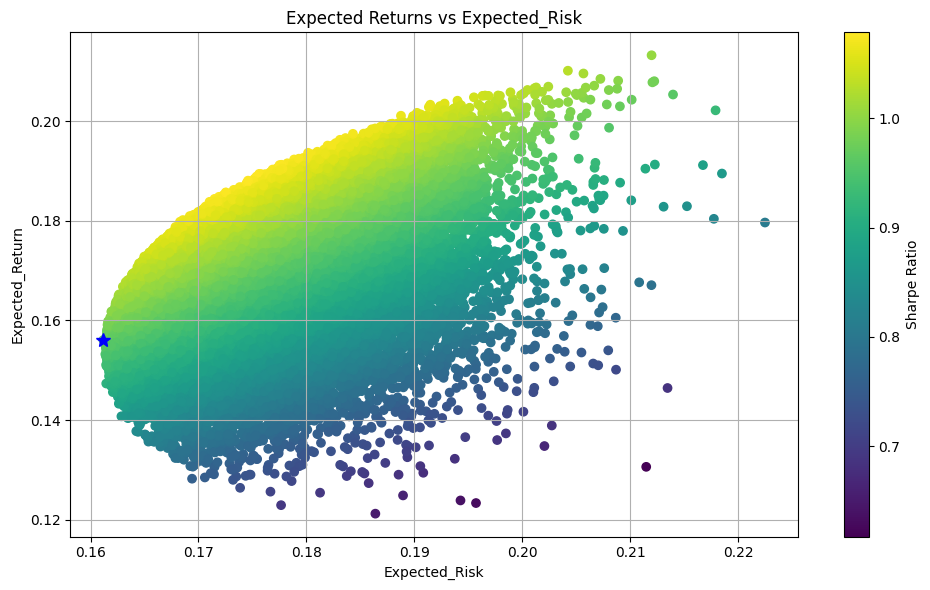

In [23]:
plt.figure(figsize=(10,6))
plt.scatter(portfolio_risk,portfolio_return,
            c=portfolio_return/portfolio_risk,marker='o')
plt.grid(True)
plt.xlabel('Expected_Risk')
plt.ylabel('Expected_Return')
plt.colorbar(label = "Sharpe Ratio")
plt.plot(portfolio_risk[ind1],portfolio_return[ind1],'b*',markersize=10.0)
plt.title("Expected Returns vs Expected_Risk")
plt.tight_layout()